[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Multiple Input and Multiple Output Channels

Every example so far has used a single two-dimensional input and a single two-dimensional output.  That was a simplification twice over.  Real images have color channels, so an RGB input has shape $3 \times h \times w$; and, as we saw when the $[1, -1]$ kernel failed to find horizontal edges, one kernel detects one kind of structure, so a useful layer needs many.

Both are the same fix: give the input and the output a **channel** axis.  This notebook works out what a convolution looks like with $c_\textrm{i}$ input channels and $c_\textrm{o}$ output channels, implements it, checks it against `nn.Conv2d`, and then looks at the curious and important special case of the $1 \times 1$ convolution.

There is also a debt to settle from notebook 2.  The derivation there ended with a layer that maps one two-dimensional grid to another.  Real images are not two-dimensional grids, so that layer, as derived, cannot be applied to a photograph.  Channels are the generalization that fixes this — and, as we will see, they are also what buys back some of the expressiveness that translation invariance and locality took away.

In [1]:
import torch
from torch import nn
import torch.nn.functional as F


def corr2d(X, K):
    """Compute the 2D cross-correlation of input X with kernel K (notebook 2)."""
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i + h, j:j + w] * K).sum()
    return Y

## Multiple input channels

When the input has several channels, the kernel needs to match: one $k_\textrm{h}\times k_\textrm{w}$ slice per input channel, giving a kernel of shape $c_\textrm{i}\times k_\textrm{h}\times k_\textrm{w}$.  We cross-correlate each input channel with its own kernel slice and **add** the $c_\textrm{i}$ results.  The sum is the essential part: the channel axis is *consumed*, so the result is again two-dimensional.

The figure shows this with two input channels.  The shaded elements give $(1\times1+2\times2+4\times3+5\times4)+(0\times0+1\times1+3\times2+4\times3)=56$.

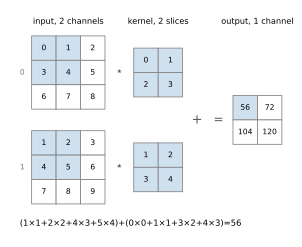

In [2]:
# this figure is drawn rather than linked, so the notebook needs no network
import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')              # crisp vector output
except ImportError:
    pass

# Shared idiom for the grid figures of this module.  Geometry is in inches and
# the axes are set so one data unit is one inch, so text never outgrows a cell.
CELL = 0.34
SHADE = '#cfe0ef'          # cells taking part in the highlighted computation
SHADE2 = '#f3ddd0'         # a second, distinct computation
PAD_FILL = '0.955'         # padding added around the input
FS = 7.6

def _grid(ax, x0, y0, values, shade=(), shade2=(), pad=(), cell=CELL, fs=FS,
          colors=None, z=2):
    """Draw a matrix with its top-left cell's top-left corner at (x0, y0).

    `z` sets the drawing order, so overlapping channel slices occlude cleanly.
    """
    from matplotlib.patches import Rectangle
    shade, shade2, pad = set(shade), set(shade2), set(pad)
    colors = colors or {}
    for r, row in enumerate(values):
        for c, v in enumerate(row):
            fill = colors.get((r, c),
                              SHADE if (r, c) in shade else
                              SHADE2 if (r, c) in shade2 else
                              PAD_FILL if (r, c) in pad else 'white')
            ax.add_patch(Rectangle((x0 + c * cell, y0 - (r + 1) * cell),
                                   cell, cell, facecolor=fill,
                                   edgecolor='0.5', linewidth=0.8, zorder=z))
            if v is not None:
                ax.text(x0 + (c + 0.5) * cell, y0 - (r + 0.5) * cell, str(v),
                        ha='center', va='center', fontsize=fs,
                        color='0.55' if (r, c) in pad else 'black', zorder=z + 1)
    return len(values[0]) * cell, len(values) * cell


def _label(ax, x, y, text, fs=8.2, weight='normal'):
    ax.text(x, y, text, ha='center', va='center', fontsize=fs, fontweight=weight)


def _op(ax, x, y, symbol):
    ax.text(x, y, symbol, ha='center', va='center', fontsize=12, color='0.35')


def _finish(fig, ax, x0, x1, y0, y1):
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.axis('off')
    fig.set_size_inches(x1 - x0, y1 - y0)
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)


def _row_layout(panels, gap=0.42, top=0.0):
    """Left-to-right x positions for a row of (width, height) panels."""
    xs, cursor = [], 0.0
    for w, h in panels:
        xs.append(cursor)
        cursor += w + gap
    return xs, cursor - gap


# ---------------------------------------------------------------- 03_02 / 03_03

def multi_channel_figure():
    """Two input channels: convolve each with its own kernel slice, then add."""
    X0 = [[0, 1, 2], [3, 4, 5], [6, 7, 8]]
    X1 = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
    K0, K1 = [[0, 1], [2, 3]], [[1, 2], [3, 4]]
    Y = [[56, 72], [104, 120]]
    win = [(0, 0), (0, 1), (1, 0), (1, 1)]

    fig, ax = plt.subplots()
    top, x, vgap = 0.0, 0.0, 0.30
    row1 = top
    row2 = top - 3 * CELL - vgap
    mid = (row1 + row2 - 3 * CELL) / 2

    w1 = 3 * CELL
    _grid(ax, x, row1, X0, shade=win)
    _grid(ax, x, row2, X1, shade=win)
    _label(ax, x + w1 / 2, top + 0.20, 'input, 2 channels')
    ax.text(x - 0.13, row1 - 1.5 * CELL, '0', ha='center', va='center',
            fontsize=7.4, color='0.45')
    ax.text(x - 0.13, row2 - 1.5 * CELL, '1', ha='center', va='center',
            fontsize=7.4, color='0.45')

    x1 = x + w1
    _op(ax, x1 + 0.20, row1 - 1.5 * CELL, r'$\star$')
    _op(ax, x1 + 0.20, row2 - 1.5 * CELL, r'$\star$')

    x2 = x1 + 0.40
    w2 = 2 * CELL
    _grid(ax, x2, row1 - CELL / 2, K0, shade=win)
    _grid(ax, x2, row2 - CELL / 2, K1, shade=win)
    _label(ax, x2 + w2 / 2, top + 0.20, 'kernel, 2 slices')

    x3 = x2 + w2
    # the two products are summed: that is what consumes the channel axis
    ax.text(x3 + 0.20, mid, '+', ha='center', va='center', fontsize=13,
            color='0.35')
    _op(ax, x3 + 0.20, mid + 0.0, '')
    x4 = x3 + 0.40
    _op(ax, x4 + 0.10, mid, '=')
    x5 = x4 + 0.30
    w3, h3 = _grid(ax, x5, mid + CELL, Y, shade=[(0, 0)])
    _label(ax, x5 + w3 / 2, top + 0.20, 'output, 1 channel')

    ax.text((x5 + w3) / 2, row2 - 3 * CELL - 0.28,
            r'$(1\times1 + 2\times2 + 4\times3 + 5\times4)'
            r' + (0\times0 + 1\times1 + 3\times2 + 4\times3) = 56$',
            ha='center', va='center', fontsize=8.4)
    _finish(fig, ax, -0.34, x5 + w3 + 0.18, row2 - 3 * CELL - 0.50, top + 0.40)

multi_channel_figure()

The implementation is one line: cross-correlate per channel, sum.

In [3]:
def corr2d_multi_in(X, K):
    """Cross-correlate a (c_i, h, w) input with a (c_i, k_h, k_w) kernel."""
    # iterate over the 0th (channel) axis of X and K together, then add up
    return sum(corr2d(x, k) for x, k in zip(X, K))

Building the input and kernel from the figure should reproduce the 56:

In [4]:
X = torch.tensor([[[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],
                  [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]])
K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]]])

Y = corr2d_multi_in(X, K)
print(Y)
assert Y[0, 0] == 56

tensor([[ 56.,  72.],
        [104., 120.]])


If the `zip` in `corr2d_multi_in` is doing something you would rather see explicitly, here is what it iterates over — the channel slices of `X` paired with the channel slices of `K`:

In [5]:
print('X', tuple(X.shape), '  K', tuple(K.shape))
for x, k in zip(X, K):
    print('  channel:', tuple(x.shape), 'against kernel slice', tuple(k.shape))

X (2, 3, 3)   K (2, 2, 2)
  channel: (3, 3) against kernel slice (2, 2)
  channel: (3, 3) against kernel slice (2, 2)


## Multiple output channels

Regardless of how many input channels we had, that gave us *one* output channel.  Every popular architecture wants more than one — and typically increases the number as the network deepens, trading spatial resolution for **channel depth**.  Intuitively, each output channel responds to a different kind of local structure: one might specialize in vertical edges, another in horizontal ones, another in a particular texture.

So build a kernel of shape $c_\textrm{i}\times k_\textrm{h}\times k_\textrm{w}$ for *every* output channel and stack them, giving a kernel tensor of shape

$$c_\textrm{o}\times c_\textrm{i}\times k_\textrm{h}\times k_\textrm{w}.$$

This four-dimensional shape is what `conv.weight.shape` reports for any PyTorch convolutional layer.  Every output channel reads *all* the input channels.

### The general form

We can now write down the layer that notebook 2 derived, in the form actually used in practice.  Indexing the input as $[\mathsf{X}]_{i, j, c}$ over height, width and channel, and the hidden representation as $[\mathsf{H}]_{i, j, d}$:

$$[\mathsf{H}]_{i,j,d} = \sum_{a = -\Delta}^{\Delta} \sum_{b = -\Delta}^{\Delta} \sum_c [\mathsf{V}]_{a, b, c, d} [\mathsf{X}]_{i+a, j+b, c},$$

where $c$ indexes input channels and $d$ output channels.  Compare it with the two-dimensional version from notebook 2: the sums over the offsets $a, b$ are untouched — translation invariance and locality still hold, and $\mathsf{V}$ still does not depend on $(i,j)$ — and all that is new is the sum over $c$ and the extra index $d$.  Channels are orthogonal to the two principles, which is exactly why we can add them without giving anything up.

Note also that $\mathsf{H}$ has the same form as $\mathsf{X}$: height, width, and a channel axis.  That is what makes these layers **stack**, and it is why the hierarchy of increasing abstraction sketched in notebook 1 is achievable at all.

In [6]:
def corr2d_multi_in_out(X, K):
    """Cross-correlate a (c_i, h, w) input with a (c_o, c_i, k_h, k_w) kernel."""
    # one call to corr2d_multi_in per output channel, stacked along a new axis
    return torch.stack([corr2d_multi_in(X, k) for k in K], 0)

We build a three-output-channel kernel by stacking `K` with `K+1` and `K+2`:

In [7]:
K = torch.stack((K, K + 1, K + 2), 0)
print(K.shape, '  # (c_o, c_i, k_h, k_w)')

torch.Size([3, 2, 2, 2])   # (c_o, c_i, k_h, k_w)


In [8]:
Y = corr2d_multi_in_out(X, K)
print(Y.shape)
Y

torch.Size([3, 2, 2])


tensor([[[ 56.,  72.],
         [104., 120.]],

        [[ 76., 100.],
         [148., 172.]],

        [[ 96., 128.],
         [192., 224.]]])

The output now has three channels, and the first of them matches the single-output-channel result from before — as it must, since the first slice of the stacked kernel is the original `K`.

The whole operation, with $c_\mathrm{i}=2$ and $c_\mathrm{o}=3$, looks like this.  The colours pair each kernel set with the output channel it produces:

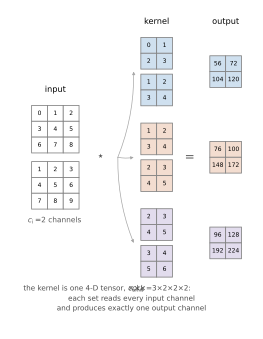

In [9]:
def multi_in_out_figure():
    """c_o kernel sets, each reading every input channel, each producing one output channel."""
    from matplotlib.patches import FancyArrowPatch
    X = [[[0, 1, 2], [3, 4, 5], [6, 7, 8]],
         [[1, 2, 3], [4, 5, 6], [7, 8, 9]]]
    Ksets = [[[[0, 1], [2, 3]], [[1, 2], [3, 4]]],
             [[[1, 2], [3, 4]], [[2, 3], [4, 5]]],
             [[[2, 3], [4, 5]], [[3, 4], [5, 6]]]]
    Yc = [[[56, 72], [104, 120]],
          [[76, 100], [148, 172]],
          [[96, 128], [192, 224]]]
    tint = ['#cfe0ef', '#f3ddd0', '#e2dced']      # one colour per output channel

    c, fs = 0.22, 6.0          # the values are incidental; keep it compact
    fig, ax = plt.subplots()
    slice_h = 2 * c                 # a kernel slice is 2x2
    inner = 0.07                       # gap between the two slices of one set
    set_h = 2 * slice_h + inner
    vgap = 0.24
    tops = [-(i * (set_h + vgap)) for i in range(3)]
    mid = (tops[0] + tops[-1] - set_h) / 2

    # the input, drawn once: every kernel set reads all of it
    x = 0.0
    w_in = 3 * c
    in_top = mid + (6 * c + 0.12) / 2
    _grid(ax, x, in_top, X[0], cell=c, fs=fs)
    _grid(ax, x, in_top - 3 * c - 0.12, X[1], cell=c, fs=fs)
    _label(ax, x + w_in / 2, in_top + 0.22, 'input')
    ax.text(x + w_in / 2, in_top - 6 * c - 0.12 - 0.16,
            r'$c_\mathrm{i} = 2$ channels', ha='center', va='center',
            fontsize=7.4, color='0.35')

    x1 = x + w_in
    _op(ax, x1 + 0.30, mid, r'$\star$')
    x2 = x1 + 0.86

    # one kernel set per output channel, each with c_i slices
    for o, (top, ks) in enumerate(zip(tops, Ksets)):
        _grid(ax, x2, top, ks[0], cell=c, fs=fs,
              colors={(r, k): tint[o] for r in range(2) for k in range(2)})
        _grid(ax, x2, top - slice_h - inner, ks[1], cell=c, fs=fs,
              colors={(r, k): tint[o] for r in range(2) for k in range(2)})
        # the same input feeds every set
        ax.add_patch(FancyArrowPatch((x1 + 0.54, mid), (x2 - 0.10, top - set_h / 2),
                                     arrowstyle='-|>', mutation_scale=6,
                                     linewidth=0.7, color='0.65',
                                     connectionstyle='arc3,rad=0.10',
                                     shrinkA=0, shrinkB=0, zorder=1))
    w_k = 2 * c
    _label(ax, x2 + w_k / 2, tops[0] + 0.22, 'kernel')


    x3 = x2 + w_k
    _op(ax, x3 + 0.24, mid, '=')
    x4 = x3 + 0.52
    for o, top in enumerate(tops):
        _grid(ax, x4, top - set_h / 2 + c, Yc[o], cell=c, fs=fs,
              colors={(r, k): tint[o] for r in range(2) for k in range(2)})
    w_y = 2 * c
    _label(ax, x4 + w_y / 2, tops[0] + 0.22, 'output')


    lo, hi = -0.34, x4 + w_y + 0.20
    ax.text((lo + hi) / 2, tops[-1] - set_h - 0.30,
            r'the kernel is one 4-D tensor, $c_\mathrm{o} \times c_\mathrm{i}'
            r' \times k_\mathrm{h} \times k_\mathrm{w} = 3 \times 2 \times 2'
            r' \times 2$:' '\neach set reads every input channel'
            '\nand produces exactly one output channel',
            ha='center', va='center', fontsize=7.2, color='0.3', linespacing=1.5)
    _finish(fig, ax, lo, hi, tops[-1] - set_h - 0.76, tops[0] + 0.42)

multi_in_out_figure()

### A version without the loop

`corr2d_multi_in_out` is written to be read: a Python loop over output channels,
each one a loop over input channels, each of those a doubly nested loop over
output positions.  Nothing in production is written that way, and it is worth
seeing what replaces it, because the answer explains a great deal about why
convolutions run fast.

Recall the $1\times1$ case we are about to reach, and the trick that makes it a
matrix multiplication: when the window is a single pixel, each output value is a
dot product between a row of the kernel and the column of channel values at that
pixel — so the whole layer is one matmul.  The general case works the same way,
once you build the right matrix.

The construction is called **im2col**.  Take every $k_\mathrm{h} \times
k_\mathrm{w}$ patch of the input, across all $c_\mathrm{i}$ channels, and flatten
it into a column; stack those columns side by side.  Flatten each of the
$c_\mathrm{o}$ kernels into a row.  Now every output value is a dot product of one
row with one column, which is precisely what matrix multiplication computes.
`torch.nn.functional.unfold` does the patch extraction.

In [10]:
def corr2d_multi_in_out_fast(X, K):
    """The same operation as a single matrix multiplication (the im2col trick)."""
    c_o, c_i, k_h, k_w = K.shape
    out_h, out_w = X.shape[1] - k_h + 1, X.shape[2] - k_w + 1
    # every kernel-sized patch of the input, flattened into a column
    patches = F.unfold(X.unsqueeze(0), (k_h, k_w)).squeeze(0)   # (c_i*k_h*k_w, L)
    # every kernel flattened into a row
    weights = K.reshape(c_o, -1)                                # (c_o, c_i*k_h*k_w)
    return (weights @ patches).reshape(c_o, out_h, out_w)

fast = corr2d_multi_in_out_fast(X, K)
print('weights', tuple(K.reshape(K.shape[0], -1).shape),
      ' @  patches', tuple(F.unfold(X.unsqueeze(0), K.shape[2:]).squeeze(0).shape))
assert torch.allclose(Y, fast, atol=1e-5)
print('matches the loop version')

weights (3, 8)  @  patches (8, 4)
matches the loop version


Every tensor in that function changes shape, so it is worth seeing them all at once:

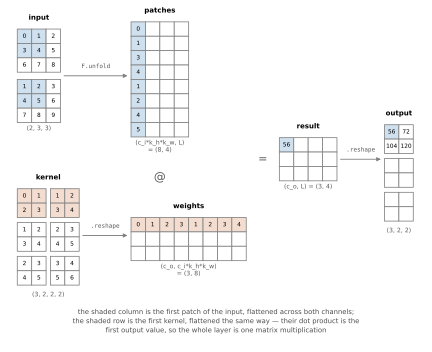

In [11]:
def im2col_figure():
    """How the tensors are reshaped so that a convolution becomes one matmul."""
    from matplotlib.patches import FancyArrowPatch
    c, fs = 0.20, 5.8
    warm = SHADE2

    X = [[[0, 1, 2], [3, 4, 5], [6, 7, 8]],
         [[1, 2, 3], [4, 5, 6], [7, 8, 9]]]
    patch_col = [0, 1, 3, 4, 1, 2, 4, 5]        # the first column of `patches`
    weight_row = [0, 1, 2, 3, 1, 2, 3, 4]       # the first row of `weights`
    Ksets = [[[[0, 1], [2, 3]], [[1, 2], [3, 4]]],
             [[[1, 2], [3, 4]], [[2, 3], [4, 5]]],
             [[[2, 3], [4, 5]], [[3, 4], [5, 6]]]]

    fig, ax = plt.subplots()

    def arrow(x0, y0, x1, y1, text):
        ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle='-|>',
                                     mutation_scale=8, linewidth=0.9, color='0.5',
                                     shrinkA=0, shrinkB=0, zorder=1))
        ax.text((x0 + x1) / 2, y0 + 0.09, text, ha='center', va='bottom',
                fontsize=6.0, color='0.35', family='monospace')

    def cap(x, y, text):
        ax.text(x, y, text, ha='center', va='top', fontsize=6.2, color='0.35')

    # ---- row 1: the input becomes a matrix of patches -----------------------
    yA = 0.0
    xa = 0.0
    _grid(ax, xa, yA, X[0], shade=[(0, 0), (0, 1), (1, 0), (1, 1)], cell=c, fs=fs)
    _grid(ax, xa, yA - 3 * c - 0.10, X[1], shade=[(0, 0), (0, 1), (1, 0), (1, 1)],
          cell=c, fs=fs)
    wa = 3 * c
    ax.text(xa + wa / 2, yA + 0.13, 'input', ha='center', fontsize=7, fontweight='bold')
    cap(xa + wa / 2, yA - 6 * c - 0.14, '(2, 3, 3)')

    xb = xa + wa + 0.98
    arrow(xa + wa + 0.05, yA - 3 * c - 0.05, xb - 0.05, yA - 3 * c - 0.05,
          'F.unfold')
    patches = [[v if j == 0 else None for j in range(4)] for v in patch_col]
    wb, hb = _grid(ax, xb, yA + 0.5 * c, patches,
                   shade=[(r, 0) for r in range(8)], cell=c, fs=fs)
    ax.text(xb + wb / 2, yA + 0.5 * c + 0.13, 'patches', ha='center', fontsize=7,
            fontweight='bold')
    cap(xb + wb / 2, yA + 0.5 * c - hb - 0.04,
        '(c_i*k_h*k_w, L)\n= (8, 4)')

    # ---- row 2: the kernel becomes a matrix of rows -------------------------
    yB = yA - 8 * c - 0.62
    xa2 = 0.0
    for o, ks in enumerate(Ksets):
        yo = yB - o * (2 * c + 0.07)
        col = {(r, cc): warm for r in range(2) for cc in range(2)} if o == 0 else None
        _grid(ax, xa2, yo, ks[0], cell=c, fs=fs, colors=col)
        _grid(ax, xa2 + 2 * c + 0.06, yo, ks[1], cell=c, fs=fs, colors=col)
    wa2 = 4 * c + 0.06
    ax.text(xa2 + wa2 / 2, yB + 0.13, 'kernel', ha='center', fontsize=7,
            fontweight='bold')
    cap(xa2 + wa2 / 2, yB - 3 * (2 * c + 0.07) - 0.02, '(3, 2, 2, 2)')

    xb2 = xb
    arrow(xa2 + wa2 + 0.05, yB - 3 * c - 0.05, xb2 - 0.05, yB - 3 * c - 0.05,
          '.reshape')
    weights = [[weight_row[j] if r == 0 else None for j in range(8)]
               for r in range(3)]
    wb2, hb2 = _grid(ax, xb2, yB - 2 * c, weights,
                     colors={(0, j): warm for j in range(8)}, cell=c, fs=fs)
    ax.text(xb2 + wb2 / 2, yB - 2 * c + 0.13, 'weights', ha='center', fontsize=7,
            fontweight='bold')
    cap(xb2 + wb2 / 2, yB - 2 * c - hb2 - 0.04, '(c_o, c_i*k_h*k_w)\n= (3, 8)')

    # ---- the multiplication and the reshape back ---------------------------
    xc = max(xb + wb, xb2 + wb2) + 0.46
    y_mid = (yA - 4 * c + yB - 3 * c) / 2
    ax.text(xb + wb / 2, (yA + 0.5 * c - hb + yB - 2 * c) / 2, '@', ha='center',
            va='center', fontsize=12, color='0.35')
    ax.text(xc - 0.23, y_mid, '=', ha='center', va='center', fontsize=11,
            color='0.35')
    result = [[56 if (r, j) == (0, 0) else None for j in range(4)] for r in range(3)]
    wc, hc = _grid(ax, xc, y_mid + 1.5 * c, result, shade=[(0, 0)], cell=c, fs=fs)
    ax.text(xc + wc / 2, y_mid + 1.5 * c + 0.13, 'result', ha='center', fontsize=7,
            fontweight='bold')
    cap(xc + wc / 2, y_mid + 1.5 * c - hc - 0.04, '(c_o, L) = (3, 4)')

    xd = xc + wc + 0.66
    arrow(xc + wc + 0.05, y_mid, xd - 0.05, y_mid, '.reshape')
    for o in range(3):
        yo = y_mid + 2.4 * c - o * (2 * c + 0.07)
        _grid(ax, xd, yo, [[56, 72], [104, 120]] if o == 0 else [[None, None],
              [None, None]], shade=[(0, 0)] if o == 0 else (), cell=c, fs=fs)
    wd = 2 * c
    ax.text(xd + wd / 2, y_mid + 2.4 * c + 0.13, 'output', ha='center',
            fontsize=7, fontweight='bold')
    cap(xd + wd / 2, y_mid + 2.4 * c - 3 * (2 * c + 0.07) - 0.02, '(3, 2, 2)')

    lo, hi = -0.14, xd + wd + 0.16
    ax.text((lo + hi) / 2, yB - 3 * (2 * c + 0.07) - 0.26,
            'the shaded column is the first patch of the input, flattened across both '
            'channels;\nthe shaded row is the first kernel, flattened the same way — '
            'their dot product is the\nfirst output value, so the whole layer is one '
            'matrix multiplication',
            ha='center', va='top', fontsize=6.8, color='0.3', linespacing=1.5)
    _finish(fig, ax, lo, hi, yB - 3 * (2 * c + 0.07) - 0.76, yA + 0.30)

im2col_figure()

The two shapes printed above are the whole idea: a $3 \times 8$ matrix of
weights times an $8 \times 4$ matrix of patches, giving the $3 \times 4$ output
that reshapes into three $2 \times 2$ channels.

It is worth timing on something big enough to matter.

In [12]:
import time

X_big = torch.randn(8, 32, 32)
K_big = torch.randn(16, 8, 3, 3)

start = time.time()
slow = corr2d_multi_in_out(X_big, K_big)
t_slow = time.time() - start

start = time.time()
quick = corr2d_multi_in_out_fast(X_big, K_big)
t_quick = time.time() - start

print(f'loop   {t_slow * 1000:8.1f} ms')
print(f'im2col {t_quick * 1000:8.1f} ms   ({t_slow / t_quick:.0f}x faster)')
assert torch.allclose(slow, quick, atol=1e-4)

loop      630.2 ms
im2col      0.2 ms   (2973x faster)


Three orders of magnitude, and not because the arithmetic changed — both
versions perform exactly the same multiplications and additions.  What changed is
who performs them.  The loop version does them one at a time in the Python
interpreter; the im2col version hands a single large matrix multiplication to a
library routine written for exactly this.

That routine has a name worth knowing: **GEMM**, for *GEneral Matrix Multiply*.
It is the level-3 routine of BLAS, the Basic Linear Algebra Subprograms
interface, and it computes $C \leftarrow \alpha AB + \beta C$.  GEMM is
plausibly the most heavily optimized piece of code in computing: implementations
such as OpenBLAS, Intel's MKL and Apple's Accelerate are hand-written in assembly,
blocked so that submatrices fit in each level of cache, and vectorized against
whatever SIMD instructions the processor offers.  Decades of effort have gone
into it, because so much numerical computing bottoms out there.

Which is why *reducing your computation to a GEMM* is the central performance
move in deep learning.  A fully connected layer is a GEMM.  Attention is a
sequence of GEMMs.  Convolution, as we have just seen, can be made into one.
The pattern is so dominant that hardware now chases it in the other direction:
the tensor cores on a modern GPU are, essentially, small GEMM engines cast into
silicon.

This is also the answer to a question the AlexNet notebook will raise.  GPUs are
not fast at convolution as such — they are fast at matrix multiplication, and
convolution is turned into matrix multiplication to take advantage of that.  The
im2col construction costs memory (each input value is copied into as many columns
as it participates in patches), which is why production kernels use more
sophisticated variants; but the principle is the one above.

### Is this what PyTorch does?

Partly, and you can watch it decide.  PyTorch does not have one convolution
implementation, it has several, and it picks per call based on the shapes, the
data type and which libraries were compiled in.  The profiler reports which one
ran.

In [13]:
from torch.profiler import profile, ProfilerActivity

BACKENDS = {
    '_slow_conv2d_forward':
        "ATen's reference kernel: im2col + GEMM, exactly what we wrote above",
    'mkldnn_convolution':
        'oneDNN: a blocked direct convolution that never builds the patch matrix',
    '_nnpack_spatial_convolution':
        'NNPACK: Winograd and FFT-based tiled convolution, fewer multiplies',
    'cudnn_convolution':
        'cuDNN: implicit GEMM, Winograd or FFT, chosen per shape',
    '_mps_convolution':
        'Apple Metal Performance Shaders: algorithm not published',
}
GENERIC = {'aten::conv2d', 'aten::convolution', 'aten::_convolution',
           'aten::thnn_conv2d', 'aten::_convolution_mode'}

def which_kernel(X, K, label, device='cpu'):
    """Report which convolution implementation PyTorch dispatches to, and what it does."""
    X, K = X.to(device), K.to(device)
    with profile(activities=[ProfilerActivity.CPU]) as prof:
        F.conv2d(X, K)
    chosen = [e.key.split('::')[1] for e in prof.key_averages()
              if e.key.startswith('aten::') and 'conv' in e.key
              and e.key not in GENERIC]
    print(f'{label}:')
    for name in chosen or ['(none found)']:
        print(f'  {name}')
        print(f'      {BACKENDS.get(name, "a backend not in the table above")}')

small = (torch.randn(1, 8, 32, 32), torch.randn(16, 8, 3, 3))
large = (torch.randn(32, 64, 56, 56), torch.randn(128, 64, 3, 3))

which_kernel(*small, 'our toy shapes')
which_kernel(*large, 'a realistic layer')
if torch.backends.mps.is_available():
    which_kernel(*large, 'the same layer on the Mac GPU', device='mps')
elif torch.cuda.is_available():
    which_kernel(*large, 'the same layer on the GPU', device='cuda')

our toy shapes:
  _slow_conv2d_forward
      ATen's reference kernel: im2col + GEMM, exactly what we wrote above
a realistic layer:
  _nnpack_spatial_convolution
      NNPACK: Winograd and FFT-based tiled convolution, fewer multiplies
the same layer on the Mac GPU:
  _mps_convolution
      Apple Metal Performance Shaders: algorithm not published


On the toy shapes you should see `_slow_conv2d_forward`.  That is PyTorch's
reference implementation, and it is **exactly the algorithm we just wrote** — an
im2col copy followed by a GEMM, in C++ rather than Python.  So the answer to "is
this how it is really done" is yes, for the fallback path.

For the realistic layer you will see something else, and *which* something else
depends on your machine, because PyTorch links against whichever kernel libraries
were available when it was built:

* **oneDNN** (`mkldnn_convolution`) — Intel's oneAPI Deep Neural Network Library,
  formerly MKL-DNN, the usual choice on x86.  It performs a *blocked direct*
  convolution, reordering the loops for cache locality and accumulating straight
  into the output, without forming patches at all.
* **NNPACK** (`_nnpack_spatial_convolution`) — a CPU library aimed at ARM, so
  this is what you are likely to see on an Apple-Silicon Mac.  It does not
  compute the dot products at all: for $3\times3$ kernels it uses a **Winograd**
  transform, otherwise an FFT-based tiled convolution.  Both trade
  multiplications for additions and perform strictly *fewer* multiplies than the
  definition calls for.
* **cuDNN** (`cudnn_convolution`) — NVIDIA's library, on a CUDA GPU.  It chooses
  per shape among several algorithms.  The workhorse is *implicit* GEMM: the same
  matrix multiplication, with the patch matrix generated on the fly in fast
  memory rather than materialized.  For $3\times3$ stride-1 layers it will often
  pick Winograd here too.
* **Metal Performance Shaders** (`_mps_convolution`) — Apple's GPU library, which
  is what the last line above reports if you move the tensors to the `mps`
  device.  Unlike the others this one is closed: Apple publishes the interface
  but not the algorithm, so the profiler can tell you *that* MPS handled the
  layer and not *how*.

### What im2col actually costs

It is worth being precise about the price, because it is easy to state it too
simply.  The patch matrix holds each input value once for every patch it belongs
to — up to $k_\mathrm{h} k_\mathrm{w}$ copies, so ninefold for a $3\times3$
kernel.

On a GPU that can be a capacity problem outright.  Activations for a large batch
are already most of what occupies video memory, and a ninefold copy of them may
simply not fit.  On a CPU with tens of gigabytes of RAM, capacity is rarely the
binding constraint — but the cost does not disappear, it changes form.  Writing a
buffer nine times the size of the input and immediately reading it back again is
memory traffic that computes nothing, and on current hardware moving a number
costs more than multiplying it.  The objection applies to both, for different
reasons.

Which is why the faster kernels are mostly not *alternatives* to im2col but
im2col performed **incrementally**: build one tile of the patch matrix, small
enough to sit in cache or in a GPU's shared memory, multiply it, discard it, and
move on.  cuDNN's implicit GEMM is that idea taken to its limit — the patch
matrix is never written down at all, only produced as the multiplication consumes
it.  oneDNN reorders the loops to get the same locality without forming patches;
NNPACK changes the arithmetic instead.

So: im2col plus GEMM is the reference implementation, the mental model that
explains why convolution is fast, and the baseline every other method is measured
against.  What the production kernels avoid is not the idea but the *buffer*.

### Checking against `nn.Conv2d`

Time to verify against the library.  `F.conv2d` wants a batch axis on the input, and takes the kernel in exactly the $(c_\textrm{o}, c_\textrm{i}, k_\textrm{h}, k_\textrm{w})$ layout we just built — so the only work is adding and removing the batch axis:

In [14]:
theirs = F.conv2d(X.unsqueeze(0), K).squeeze(0)   # add, then drop, the batch axis
print('max difference:', (Y - theirs).abs().max().item())
assert torch.allclose(Y, theirs, atol=1e-5)
print('match!')

max difference: 0.0
match!


It is worth seeing the same shapes on a real layer, where the kernel is a learned parameter rather than something we constructed.  Note that the bias has one entry per output channel — a single scalar added to the whole feature map, which is what translation invariance requires:

In [15]:
conv = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=5)
print('weight', tuple(conv.weight.shape), '= (c_o, c_i, k_h, k_w)')
print('bias  ', tuple(conv.bias.shape), '= one per output channel')
print('parameters:', sum(p.numel() for p in conv.parameters()),
      '=', 8 * 3 * 5 * 5, '+', 8)

weight (8, 3, 5, 5) = (c_o, c_i, k_h, k_w)
bias   (8,) = one per output channel
parameters: 608 = 600 + 8


## The $1\times 1$ convolutional layer

A $1 \times 1$ convolution — $k_\textrm{h} = k_\textrm{w} = 1$ — looks pointless at first.  The whole purpose of a convolution is to relate adjacent pixels, and a $1 \times 1$ window has no neighbors.  Yet it appears throughout modern architectures, starting with [Network in Network](https://arxiv.org/abs/1312.4400), and it is worth understanding why.

Because the window is minimal, the only computation left happens **along the channel axis**.  Each output element is a linear combination of the input values *at the same spatial position*, across channels.

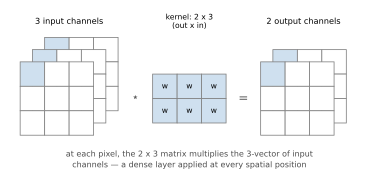

In [16]:
def one_by_one_figure():
    """A 1x1 convolution mixes channels at a fixed spatial position and nothing else."""
    fig, ax = plt.subplots()
    top, x, off = 0.0, 0.0, 0.17
    blank = [[None] * 3 for _ in range(3)]

    # three input channels, drawn as a stack; the same pixel shaded in each
    for d in (2, 1, 0):
        _grid(ax, x + d * off, top + d * off, blank,
              shade=[(0, 0)], z=2 + 2 * (2 - d))
    w1 = 3 * CELL + 2 * off
    _label(ax, x + w1 / 2, top + 0.56, '3 input channels')

    x1 = x + w1
    _op(ax, x1 + 0.24, top - 3 * CELL / 2, r'$\star$')

    # the kernel is a 2x3 matrix of scalars: one row per output channel
    x2 = x1 + 0.48
    w2, h2 = _grid(ax, x2, top - (3 * CELL - 2 * CELL) / 2,
                   [['w', 'w', 'w'], ['w', 'w', 'w']], shade=[(0, 0), (0, 1),
                    (0, 2), (1, 0), (1, 1), (1, 2)])
    _label(ax, x2 + w2 / 2, top + 0.56, 'kernel: 2 x 3\n(out x in)', fs=7.6)

    x3 = x2 + w2
    _op(ax, x3 + 0.24, top - 3 * CELL / 2, '=')

    x4 = x3 + 0.48
    for d in (1, 0):
        _grid(ax, x4 + d * off, top + d * off, blank,
              shade=[(0, 0)], z=2 + 2 * (1 - d))
    w3 = 3 * CELL + off
    _label(ax, x4 + w3 / 2, top + 0.56, '2 output channels')

    ax.text((x4 + w3 + 0.17) / 2, top - 3 * CELL - 0.34,
            'at each pixel, the 2 x 3 matrix multiplies the 3-vector of input\n'
            'channels — a dense layer applied at every spatial position',
            ha='center', va='center', fontsize=8, color='0.3', linespacing=1.5)
    _finish(fig, ax, -0.18, x4 + w3 + 0.34, top - 3 * CELL - 0.62, top + 0.76)

one_by_one_figure()

The right way to think of it: **a $1 \times 1$ convolution is a fully connected layer applied independently at every pixel location**, mapping the $c_\textrm{i}$ values there to $c_\textrm{o}$ values, with the same weight matrix at every location.  It costs $c_\textrm{o}\times c_\textrm{i}$ weights plus the bias, and it is the standard tool for changing the number of channels without touching spatial resolution.  Since convolutional layers are followed by nonlinearities, $1 \times 1$ convolutions cannot simply be folded into the neighboring convolutions.

If the claim is that this is a matrix multiplication in disguise, we should be able to implement it as one.  Flatten the spatial axes, multiply, unflatten:

In [17]:
def corr2d_multi_in_out_1x1(X, K):
    """A 1x1 convolution, implemented as a matrix multiplication."""
    c_i, h, w = X.shape
    c_o = K.shape[0]
    X = X.reshape((c_i, h * w))    # one column per pixel
    K = K.reshape((c_o, c_i))      # the fully connected weight matrix
    Y = torch.matmul(K, X)
    return Y.reshape((c_o, h, w))

And it should agree with the general convolution code when the kernel happens to be $1 \times 1$:

In [18]:
X = torch.normal(0, 1, (3, 3, 3))
K = torch.normal(0, 1, (2, 3, 1, 1))
Y1 = corr2d_multi_in_out_1x1(X, K)
Y2 = corr2d_multi_in_out(X, K)
print('max difference:', (Y1 - Y2).abs().max().item())
assert torch.allclose(Y1, Y2, atol=1e-5)
print('match!')

max difference: 2.384185791015625e-07
match!


## The cost of channels

Channels give back much of the expressiveness that locality and translation invariance took away — but they are also where the computation goes, and it is worth knowing the arithmetic before designing a network.

For an $h \times w$ image, a single-channel $k \times k$ convolution costs $\mathcal{O}(h \cdot w \cdot k^2)$.  With $c_\textrm{i}$ input and $c_\textrm{o}$ output channels this becomes

$$\mathcal{O}(h \cdot w \cdot k^2 \cdot c_\textrm{i} \cdot c_\textrm{o}).$$

The channel term is a *product*, so doubling the width of a network quadruples the work in its convolutions.

In [19]:
def conv_cost(h, w, k, c_i, c_o):
    """Multiply-accumulate operations for one k x k convolution layer."""
    return h * w * k * k * c_i * c_o

print(f'256x256 image, 5x5 kernel, 128 -> 128 channels: '
      f'{conv_cost(256, 256, 5, 128, 128):,} operations')
print(f'                          ... with a 1x1 kernel: '
      f'{conv_cost(256, 256, 1, 128, 128):,} operations')
print(f'                    ... 5x5, but 64 -> 64 channels: '
      f'{conv_cost(256, 256, 5, 64, 64):,} operations')

256x256 image, 5x5 kernel, 128 -> 128 channels: 26,843,545,600 operations
                          ... with a 1x1 kernel: 1,073,741,824 operations
                    ... 5x5, but 64 -> 64 channels: 6,710,886,400 operations


Nearly 27 billion multiply-accumulates for a single layer — over 53 billion operations if multiplications and additions are counted separately — and this is one image, one forward pass.  The two ways of reducing it are visible in the other rows: shrink the kernel, or shrink the channel counts.  Later architectures do both — a $1 \times 1$ convolution to reduce channels, then an expensive $k \times k$ convolution on the narrower tensor, then a $1 \times 1$ to restore the width (the "bottleneck" block of ResNet), or requiring the channel-wise operation to be block-diagonal, as in grouped convolutions and ResNeXt.

## Summary

* Multiple **input channels** require a kernel slice per channel; the per-channel cross-correlations are **summed**, which collapses the channel axis.
* Multiple **output channels** require one such kernel per output channel, giving the standard four-dimensional kernel shape $(c_\textrm{o}, c_\textrm{i}, k_\textrm{h}, k_\textrm{w})$.  The bias has one entry per output channel.
* Our implementation matches `F.conv2d` exactly.
* Channels let a layer compute many kinds of local features at once — the fix for the one-orientation edge detector of notebook 2 — and are the practical counterweight to the parameter reduction that locality and translation invariance bought us.
* They are also what makes the derived layer applicable to real images, and what lets convolutional layers stack: the output of a convolution has the same form as its input.
* A $1\times 1$ convolution does no spatial mixing: it is a fully connected layer applied at each pixel, shared across positions, and is the standard way to change the number of channels.
* Convolution cost scales as $h \cdot w \cdot k^2 \cdot c_\textrm{i} \cdot c_\textrm{o}$; the channel counts enter as a product, and dominate in deep networks.

## Exercises

1. Assume we have two convolution kernels of size $k_1$ and $k_2$ respectively, with no nonlinearity in between.  Prove that the result can be expressed as a single convolution, and give the size of the equivalent kernel.  Does the reverse hold?
2. Assume an input of shape $c_\textrm{i}\times h\times w$ and a kernel of shape $c_\textrm{o}\times c_\textrm{i}\times k_\textrm{h}\times k_\textrm{w}$, padding $(p_\textrm{h}, p_\textrm{w})$, and stride $(s_\textrm{h}, s_\textrm{w})$.  What is the computational cost of the forward propagation?  What is the memory footprint?  What about the backward pass?
3. By what factor does the number of computations increase if you double both $c_\textrm{i}$ and $c_\textrm{o}$?  What happens if you double the padding?
4. Are the variables `Y1` and `Y2` in the last example exactly the same?  Why or why not?
5. Express convolutions as a matrix multiplication, even when the convolution window is not $1 \times 1$.  (Hint: the matrix has repeated entries.)
6. Take a Fashion-MNIST image, apply a `nn.Conv2d` layer with 8 randomly initialized output channels, and plot all 8 feature maps.  Then hand-set one of the kernels to the $[1, -1]$ edge detector and see which map changes.
7. The general form sums over input channels but keeps the offsets $a, b$ shared across them.  What would it mean for a layer to use a *different* $\Delta$ per input channel?  Would translation invariance survive?  Would the layer still stack?
8. Satellite and hyperspectral images have tens to hundreds of channels rather than three.  Which quantities in this notebook's cost formula grow, and which stay fixed?  What does that suggest about where to put a $1 \times 1$ convolution in such a network?